# Import Image

In [1]:
import sklearn
import sys
import matplotlib.pyplot as plt
from pathlib import Path

import urllib.request

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [2]:
import numpy as np
import PIL

image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

# Segment Image with KMeans

In [3]:
from sklearn.cluster import KMeans
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

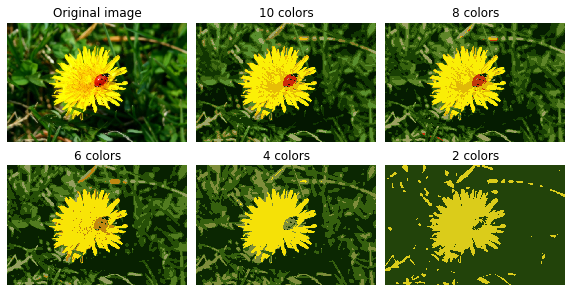

In [4]:
segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

plt.show()

# Segment Image with DBScan

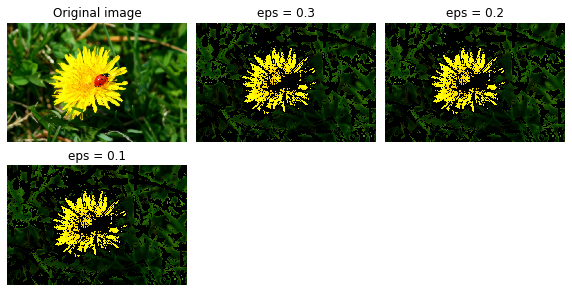

In [8]:
from sklearn.cluster import DBSCAN

segmented_imgs = []

eps_values = [0.3, 0.2, 0.1]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10).fit(X)
    labels = dbscan.labels_

    unique_labels = np.unique(labels)

    colors = np.zeros((len(unique_labels), X.shape[1]))

    for i, label in enumerate(unique_labels):
        if label == -1:
            colors[i] = np.array([0, 0, 0])
        else:
            colors[i] = X[labels == label].mean(axis=0)

    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    segmented_img = np.array([label_to_color[l] for l in labels])

    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, eps in enumerate(eps_values):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"eps = {eps}")
    plt.axis('off')

plt.show()

# Findings:

## It's interesting how you can see the colors being seperated with KMeans as it gets more green with clearer but not as bright yellow for smaller numbers of k. For DBScan the lower the eps value is, the darker the image gets. It would be interesting to see what it looks like with a higher eps value, but I was having problems getting it to run with too high of a value.